# Thu thập dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/23SE3-2025-2026/Machine Learning/Colab/End to end Machine Learning project/data/raw/e-commerce-dataset.zip'
output_directory = '/content/data/raw'

import zipfile
import tarfile
import os

os.makedirs(output_directory, exist_ok=True)

if zip_file_path.endswith('.zip'):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(output_directory)
    print(f"Đã giải nén '{zip_file_path}' vào '{output_directory}'")
elif zip_file_path.endswith('.tar.gz') or zip_file_path.endswith('.tgz'):
    with tarfile.open(zip_file_path, 'r:gz') as tar_ref:
        tar_ref.extractall(output_directory)
    print(f"Đã giải nén '{zip_file_path}' vào '{output_directory}'")
elif zip_file_path.endswith('.tar'):
    with tarfile.open(zip_file_path, 'r:') as tar_ref:
        tar_ref.extractall(output_directory)
    print(f"Đã giải nén '{zip_file_path}' vào '{output_directory}'")
else:
    print("Định dạng tệp nén không được hỗ trợ. Vui lòng cung cấp tệp .zip, .tar.gz hoặc .tar.")


Đã giải nén '/content/drive/MyDrive/23SE3-2025-2026/Machine Learning/Colab/End to end Machine Learning project/data/raw/e-commerce-dataset.zip' vào '/content/data/raw'


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import json, joblib
import matplotlib.pyplot as plt

In [ ]:
DATA_DIR = Path("data/raw")
OUT_DIR  = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TOP_K = 0.05
FILES = {
    "orders": "olist_orders_dataset.csv",
    "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "geo": "olist_geolocation_dataset.csv",
}

# 1) Xác định bài toán và chống rò rỉ dữ liệu

## 1.1 Thời điểm dự đoán
Ta cần dự đoán **ngay sau khi khách đặt hàng** (thời điểm hệ thống ghi nhận đơn hàng).  
Nói cách khác: *mô hình chỉ được phép dùng những thông tin mà hệ thống chắc chắn đã biết tại thời điểm vừa đặt hàng.*

### Được phép dùng (có sẵn ngay lúc đặt hàng)
- Thông tin đơn hàng: thời điểm đặt, tổng tiền, phí vận chuyển, số lượng sản phẩm, số người bán…
- Thông tin thanh toán: loại thanh toán, số lần trả góp, tổng giá trị thanh toán…
- Thông tin địa lý: tỉnh/thành của khách và người bán, khoảng cách ước lượng…
- Thông tin “cam kết giao”: số ngày dự kiến giao (tính từ ngày đặt đến ngày dự kiến)

### Không được phép dùng (xảy ra sau khi đặt hàng)
- Các mốc phát sinh trong quá trình xử lý/giao: ngày duyệt đơn, ngày bàn giao cho đơn vị vận chuyển, ngày giao thực tế…
- Bất kỳ dấu vết nào “biết trước tương lai” so với thời điểm dự đoán

Quy tắc kiểm tra nhanh: **Nếu một trường dữ liệu chỉ xuất hiện sau khi đơn đã được xử lý hoặc đã giao**, thì không được dùng làm đầu vào dự đoán.

---

## 1.2 Định nghĩa nhãn
Ta gán nhãn “giao trễ” như sau *(chỉ xét các đơn đã giao thành công)*:

- **Giao trễ = 1** nếu *ngày giao thực tế* **muộn hơn** *ngày dự kiến giao*  
- **Không trễ = 0** nếu *ngày giao thực tế* **không muộn hơn** *ngày dự kiến giao*


# 2) Load raw data

In [ ]:
def read_csv(name, parse_dates=None):
    path = DATA_DIR / FILES[name]
    if not path.exists():
        raise FileNotFoundError(f"Không thấy file: {path}. Hãy kiểm tra DATA_DIR/FILES.")
    return pd.read_csv(path, parse_dates=parse_dates)

orders = read_csv("orders", parse_dates=[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
items = read_csv("items")
payments = read_csv("payments")
customers = read_csv("customers")
sellers = read_csv("sellers")
products = read_csv("products")
geo = read_csv("geo")

print("orders:", orders.shape)
print("items:", items.shape)
print("payments:", payments.shape)
print("customers:", customers.shape)
print("sellers:", sellers.shape)
print("products:", products.shape)
print("geo:", geo.shape)

orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
customers: (99441, 5)
sellers: (3095, 4)
products: (32951, 9)
geo: (1000163, 5)


In [ ]:
def quick_table_report(df: pd.DataFrame, name: str, key_cols=None, show_head=5):
    """
    In báo cáo nhanh cho 1 dataframe:
    - shape, duplicates
    - missing top
    - dtype summary
    - unique count cho key columns
    - sample rows
    """
    print("\n" + "="*80)
    print(f"[{name}]")
    print("="*80)
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} cols")

    # duplicates
    dup_rows = df.duplicated().sum()
    print(f"Duplicated rows: {dup_rows:,} ({dup_rows/len(df)*100:.2f}%)" if len(df) else "Duplicated rows: N/A")

    # dtypes summary
    dtype_counts = df.dtypes.value_counts()
    print("\nDtypes:")
    for dt, cnt in dtype_counts.items():
        print(f"  - {dt}: {cnt} cols")

    # missing summary
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss_top = miss[miss > 0].head(10)
    print("\nMissingness (top 10 columns, %):")
    if len(miss_top) == 0:
        print("  - Không có missing")
    else:
        for c, v in miss_top.items():
            print(f"  - {c}: {v:.2f}%")

    # key columns uniqueness
    if key_cols:
        print("\nKey columns check:")
        for c in key_cols:
            if c in df.columns:
                nunique = df[c].nunique(dropna=True)
                na_pct = df[c].isna().mean() * 100
                print(f"  - {c}: nunique={nunique:,}, missing={na_pct:.2f}%")
            else:
                print(f"  - {c}: (không có trong bảng)")

    # show small sample
    print(f"\nSample rows (first {show_head}):")
    display(df.head(show_head))


reports = [
    ("orders", orders, ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]),
    ("items", items, ["order_id", "order_item_id", "product_id", "seller_id"]),
    ("payments", payments, ["order_id", "payment_type"]),
    ("customers", customers, ["customer_id", "customer_unique_id", "customer_zip_code_prefix", "customer_state"]),
    ("sellers", sellers, ["seller_id", "seller_zip_code_prefix", "seller_state"]),
    ("products", products, ["product_id", "product_category_name"]),
    ("geo", geo, ["geolocation_zip_code_prefix", "geolocation_state", "geolocation_city"]),
]

for name, df_, keys in reports:
    quick_table_report(df_, name=name, key_cols=keys, show_head=5)



[orders]
Shape: 99,441 rows x 8 cols
Duplicated rows: 0 (0.00%)

Dtypes:
  - datetime64[ns]: 5 cols
  - object: 3 cols

Missingness (top 10 columns, %):
  - order_delivered_customer_date: 2.98%
  - order_delivered_carrier_date: 1.79%
  - order_approved_at: 0.16%

Key columns check:
  - order_id: nunique=99,441, missing=0.00%
  - customer_id: nunique=99,441, missing=0.00%
  - order_status: nunique=8, missing=0.00%
  - order_purchase_timestamp: nunique=98,875, missing=0.00%

Sample rows (first 5):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26



[items]
Shape: 112,650 rows x 7 cols
Duplicated rows: 0 (0.00%)

Dtypes:
  - object: 4 cols
  - float64: 2 cols
  - int64: 1 cols

Missingness (top 10 columns, %):
  - Không có missing

Key columns check:
  - order_id: nunique=98,666, missing=0.00%
  - order_item_id: nunique=21, missing=0.00%
  - product_id: nunique=32,951, missing=0.00%
  - seller_id: nunique=3,095, missing=0.00%

Sample rows (first 5):


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



[payments]
Shape: 103,886 rows x 5 cols
Duplicated rows: 0 (0.00%)

Dtypes:
  - object: 2 cols
  - int64: 2 cols
  - float64: 1 cols

Missingness (top 10 columns, %):
  - Không có missing

Key columns check:
  - order_id: nunique=99,440, missing=0.00%
  - payment_type: nunique=5, missing=0.00%

Sample rows (first 5):


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



[products]
Shape: 32,951 rows x 9 cols
Duplicated rows: 0 (0.00%)

Dtypes:
  - float64: 7 cols
  - object: 2 cols

Missingness (top 10 columns, %):
  - product_category_name: 1.85%
  - product_description_lenght: 1.85%
  - product_name_lenght: 1.85%
  - product_photos_qty: 1.85%
  - product_weight_g: 0.01%
  - product_height_cm: 0.01%
  - product_length_cm: 0.01%
  - product_width_cm: 0.01%

Key columns check:
  - product_id: nunique=32,951, missing=0.00%
  - product_category_name: nunique=73, missing=1.85%

Sample rows (first 5):


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



[geo]
Shape: 1,000,163 rows x 5 cols
Duplicated rows: 261,831 (26.18%)

Dtypes:
  - float64: 2 cols
  - object: 2 cols
  - int64: 1 cols

Missingness (top 10 columns, %):
  - Không có missing

Key columns check:
  - geolocation_zip_code_prefix: nunique=19,015, missing=0.00%
  - geolocation_state: nunique=27, missing=0.00%
  - geolocation_city: nunique=8,011, missing=0.00%

Sample rows (first 5):


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


# 3) Xây dựng bảng dữ liệu theo cấp đơn hàng

## Mục tiêu
Trong bộ dữ liệu thương mại điện tử, thông tin thường nằm rải rác ở nhiều bảng và **một đơn hàng có thể có nhiều dòng** ở các bảng con (ví dụ: mỗi sản phẩm trong giỏ là một dòng, mỗi lần thanh toán là một dòng…).  
Vì bài toán của chúng ta là **dự đoán đơn hàng giao trễ hay không**, nên **đơn vị dự đoán** phải là **mỗi đơn hàng = một dòng dữ liệu**.

Nói cách khác: ta cần tạo một bảng cuối cùng tên là **`order_level`** sao cho:
- **Mỗi dòng tương ứng đúng 1 `order_id`**
- Tập đặc trưng (các cột) mô tả đầy đủ đơn hàng tại thời điểm khách đặt

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 6371.0 * (2*np.arcsin(np.sqrt(a)))

### (1) Gộp dữ liệu từ bảng “sản phẩm trong đơn” về mức đơn hàng
Bảng sản phẩm trong đơn (order_items) là dữ liệu theo từng dòng sản phẩm, nên một `order_id` có nhiều dòng.  
Ta sẽ **tổng hợp** để tạo ra các đặc trưng cấp đơn hàng như:
- số lượng sản phẩm trong đơn
- tổng giá trị hàng hoá
- tổng phí vận chuyển
- số lượng sản phẩm khác nhau
- số lượng người bán khác nhau

In [ ]:
items_agg = (
    items.groupby("order_id")
    .agg(
        num_items=("order_item_id", "count"),
        items_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
    )
    .reset_index()
)
items_agg.head()

,order_id,num_items,items_value,freight_value,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1


### (2) Bổ sung đặc trưng về sản phẩm (khối lượng, thể tích) rồi gộp theo đơn hàng
Bảng sản phẩm (products) chứa thông tin như khối lượng, kích thước… theo từng `product_id`.  
Ta nối nó vào bảng item-level, sau đó tiếp tục **tổng hợp theo `order_id`** để có các đặc trưng:
- tổng khối lượng của đơn
- tổng thể tích ước lượng của đơn

In [ ]:
prod_cols = [c for c in products.columns if c.startswith("product_")]
item_prod = items.merge(products[prod_cols], on="product_id", how="left")

if set(["product_length_cm","product_height_cm","product_width_cm"]).issubset(item_prod.columns):
    item_prod["product_volume_cm3"] = (
        item_prod["product_length_cm"].fillna(0)
        * item_prod["product_height_cm"].fillna(0)
        * item_prod["product_width_cm"].fillna(0)
    )
else:
    item_prod["product_volume_cm3"] = np.nan

prod_agg = (
    item_prod.groupby("order_id")
    .agg(
        total_weight_g=("product_weight_g", "sum"),
        total_volume_cm3=("product_volume_cm3", "sum"),
    )
    .reset_index()
)
prod_agg.head()

,order_id,total_weight_g,total_volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,14157.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,2400.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,42000.0


### (3) Gộp dữ liệu thanh toán về mức đơn hàng
Bảng thanh toán (payments) cũng có thể có nhiều dòng cho một đơn (nhiều hình thức thanh toán hoặc nhiều lần).  
Ta tổng hợp để lấy:
- tổng số tiền thanh toán
- số lần trả góp lớn nhất
- số loại thanh toán khác nhau
- loại thanh toán phổ biến nhất

In [ ]:
def most_frequent(series):
    series = series.dropna()
    if len(series) == 0:
        return np.nan
    return series.value_counts().idxmax()

pay_agg = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        installments_max=("payment_installments", "max"),
        payment_types_nunique=("payment_type", "nunique"),
        payment_type_main=("payment_type", most_frequent),
    )
    .reset_index()
)
pay_agg.head()

,order_id,payment_value,installments_max,payment_types_nunique,payment_type_main
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


### (4) Thêm thông tin vị trí khách hàng và người bán, ước lượng khoảng cách
Ta nối thêm:
- tỉnh/thành của khách hàng và người bán
- toạ độ (vĩ độ, kinh độ) theo mã bưu chính rút gọn

Vì bảng toạ độ thường có nhiều dòng cho một mã bưu chính, ta lấy **trung bình toạ độ** theo mã bưu chính để ổn định.

Sau đó, dùng công thức khoảng cách trên bề mặt trái đất để tính:
- **khoảng cách ước lượng giữa khách và người bán (km)**
- biến nhị phân: khách và người bán **khác tỉnh** hay không

In [ ]:
geo_agg = (
    geo.groupby("geolocation_zip_code_prefix")
    .agg(geo_lat=("geolocation_lat","mean"), geo_lng=("geolocation_lng","mean"))
    .reset_index()
    .rename(columns={"geolocation_zip_code_prefix":"zip_prefix"})
)

cust_geo = customers.rename(columns={"customer_zip_code_prefix":"zip_prefix"}).merge(
    geo_agg, on="zip_prefix", how="left"
).rename(columns={"geo_lat":"cust_lat","geo_lng":"cust_lng"})

sell_geo = sellers.rename(columns={"seller_zip_code_prefix":"zip_prefix"}).merge(
    geo_agg, on="zip_prefix", how="left"
).rename(columns={"geo_lat":"sell_lat","geo_lng":"sell_lng"})

geo_agg.head()

,zip_prefix,geo_lat,geo_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


### (5) Nối tất cả vào bảng đơn hàng chính để tạo `order_level`
Cuối cùng, ta lấy bảng đơn hàng (orders) làm “xương sống”, rồi lần lượt nối các bảng đã tổng hợp:
- đặc trưng giỏ hàng (từ items đã gộp)
- đặc trưng sản phẩm (từ products đã gộp)
- đặc trưng thanh toán (từ payments đã gộp)
- đặc trưng địa lý (customer/seller + khoảng cách)

In [ ]:
order_level = orders.merge(items_agg, on="order_id", how="left") \
                    .merge(prod_agg, on="order_id", how="left") \
                    .merge(pay_agg, on="order_id", how="left")

order_level = order_level.merge(
    cust_geo[["customer_id","customer_state","cust_lat","cust_lng"]],
    on="customer_id", how="left"
)

main_seller = items.sort_values(["order_id","order_item_id"]).groupby("order_id").first().reset_index()[["order_id","seller_id"]]
order_level = order_level.merge(main_seller, on="order_id", how="left")

order_level = order_level.merge(
    sell_geo[["seller_id","seller_state","sell_lat","sell_lng"]],
    on="seller_id", how="left"
)

order_level["inter_state"] = (order_level["customer_state"] != order_level["seller_state"]).astype(float)

mask = order_level[["cust_lat","cust_lng","sell_lat","sell_lng"]].notna().all(axis=1)
order_level["distance_km"] = np.nan
order_level.loc[mask, "distance_km"] = haversine_km(
    order_level.loc[mask,"cust_lat"], order_level.loc[mask,"cust_lng"],
    order_level.loc[mask,"sell_lat"], order_level.loc[mask,"sell_lng"]
)
order_level.head()
order_level.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,num_items,items_value,freight_value,unique_products,unique_sellers,...,total_volume_cm3,payment_value,installments_max,payment_types_nunique,cust_lat,cust_lng,sell_lat,sell_lng,inter_state,distance_km
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,...,9.866600e+04,99440.000000,99440.000000,99440.000000,99163.000000,99163.000000,98448.000000,98448.000000,99441.000000,98175.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,1.141731,137.754076,22.823562,1.038098,1.013622,...,1.740143e+04,160.990267,2.930521,1.022586,-21.191224,-46.175442,-22.793764,-47.220540,0.643216,601.654691
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,0.850000,0.000000,1.000000,1.000000,...,0.000000e+00,0.000000,0.000000,1.000000,-33.689948,-72.668881,-32.079231,-67.813284,0.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,1.000000,45.900000,13.850000,1.000000,1.000000,...,2.964000e+03,62.010000,1.000000,1.000000,-23.589378,-48.097950,-23.612734,-48.784496,0.000000,185.722082
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,1.000000,86.900000,17.170000,1.000000,1.000000,...,7.260000e+03,105.290000,2.000000,1.000000,-22.924970,-46.630647,-23.425556,-46.743468,1.000000,433.792048
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,1.000000,149.900000,24.040000,1.000000,1.000000,...,1.987200e+04,176.970000,4.000000,1.000000,-20.139828,-43.598897,-21.757321,-46.518679,1.000000,799.336216
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,13440.000000,1794.960000,8.000000,5.000000,...,1.476000e+06,13664.080000,24.000000,2.000000,42.184003,-8.723762,-2.501242,-34.855616,1.000000,8677.911622
std,NaN,NaN,NaN,NaN,NaN,0.538452,210.645145,21.650909,0.226456,0.122297,...,3.040217e+04,221.951257,2.715685,0.148582,5.608637,4.056067,2.750130,2.350240,0.479053,595.200118


---
# 4) Tạo nhãn mục tiêu và danh sách cột bị cấm (chống rò rỉ dữ liệu)

Sau khi đã có bảng dữ liệu theo cấp **đơn hàng** (mỗi đơn một dòng), bước tiếp theo là:
1) chọn các đơn đủ điều kiện để huấn luyện,
2) tạo **nhãn giao trễ** cho bài toán phân loại,
3) tạo thêm một số đặc trưng về thời gian (có sẵn tại thời điểm đặt hàng),
4) và quan trọng nhất: lập danh sách **cột bị cấm** để tránh rò rỉ dữ liệu tương lai.

---

## 4.1 Lọc các đơn đủ điều kiện (chỉ xét đơn đã giao thành công)
Vì nhãn “giao trễ” cần so sánh *ngày giao thực tế* với *ngày dự kiến*, nên ta chỉ sử dụng các đơn:
- có trạng thái **đã giao thành công**,
- có đủ các mốc thời gian quan trọng:
  - thời điểm đặt hàng,
  - ngày dự kiến giao,
  - ngày giao thực tế.

Mục tiêu của bước này là đảm bảo dữ liệu huấn luyện **không thiếu thông tin để tạo nhãn** và tránh nhiễu do các đơn chưa giao.

---

## 4.2 Tạo nhãn `late` (giao trễ hay không)
Ta định nghĩa nhãn như sau:
- `late = 1` nếu **ngày giao thực tế muộn hơn ngày dự kiến**
- `late = 0` nếu **ngày giao thực tế không muộn hơn ngày dự kiến**

Như vậy, đây là bài toán **phân loại nhị phân**: dự đoán một đơn hàng có trễ hay không.

> Lưu ý: các cột “ngày giao thực tế” và “ngày dự kiến giao” chỉ dùng để tạo nhãn / hậu kiểm, không được đưa vào đặc trưng đầu vào của mô hình.

---

## 4.3 Tạo đặc trưng thời gian và “thời gian cam kết”
Các đặc trưng thời gian giúp mô hình nắm bắt:
- xu hướng theo mùa (tháng),
- khác biệt theo ngày trong tuần,
- khác biệt theo giờ đặt hàng,
- và độ dài thời gian giao hàng dự kiến.

Ví dụ các đặc trưng có thể tạo:
- **Giờ đặt hàng** (0–23)
- **Ngày trong tuần** (0–6)
- **Tháng** (1–12)
- **Số ngày cam kết giao hàng**  
  = (ngày dự kiến giao) − (thời điểm đặt hàng)

Quan trọng: các đặc trưng này **đều có thể biết ngay lúc đặt hàng**, nên không gây rò rỉ dữ liệu tương lai.

---

## 4.4 Danh sách cột bị cấm (`FORBIDDEN`) để chống rò rỉ dữ liệu
Đây là bước “kỷ luật dữ liệu” rất quan trọng trong dự án máy học.

**Các cột bị cấm** là những cột:
- chỉ xuất hiện sau thời điểm đặt hàng (tương lai),
- hoặc là “thông tin trợ giúp tạo nhãn” (nếu đưa vào mô hình sẽ làm mô hình gian lận).


In [ ]:
df = order_level.copy()

df = df[df["order_status"] == "delivered"].copy()
df = df[df["order_delivered_customer_date"].notna() & df["order_estimated_delivery_date"].notna() & df["order_purchase_timestamp"].notna()].copy()

df["late"] = (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]).astype(int)

df["actual_lead_time_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / (3600*24)
df["promised_lead_time_days"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / (3600*24)

ts = df["order_purchase_timestamp"]
df["order_hour"] = ts.dt.hour
df["order_dow"] = ts.dt.dayofweek
df["order_month"] = ts.dt.month

print("After filtering delivered:", df.shape, "Late rate:", df["late"].mean())

After filtering delivered: (96470, 34) Late rate: 0.08112366538820359


In [ ]:
FORBIDDEN = [
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
    "order_approved_at",
    "order_estimated_delivery_date",
    "actual_lead_time_days",
    "order_status",
]
print("Forbidden columns:", FORBIDDEN)

Forbidden columns: ['order_delivered_customer_date', 'order_delivered_carrier_date', 'order_approved_at', 'order_estimated_delivery_date', 'actual_lead_time_days', 'order_status']


In [ ]:
display(df.head())
processed_path = OUT_DIR / "order_level.parquet"
df.to_parquet(processed_path, index=False)
print("Saved processed:", processed_path)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,num_items,items_value,...,sell_lat,sell_lng,inter_state,distance_km,late,actual_lead_time_days,promised_lead_time_days,order_hour,order_dow,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,29.99,...,-23.680729,-46.444238,0.0,18.576110,0,8.436574,15.544063,10,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,118.70,...,-19.807681,-43.980427,1.0,851.495069,0,13.782037,19.137766,20,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,159.90,...,-21.363502,-48.229601,1.0,514.410666,0,9.394213,26.639711,8,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,45.00,...,-19.837682,-43.924053,1.0,1822.226336,0,13.208750,26.188819,19,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,19.90,...,-23.543395,-46.262086,0.0,29.676625,0,2.873877,12.112049,21,1,2


Saved processed: data/processed/order_level.parquet



# 5) Chia tập huấn luyện / kiểm tra theo thời gian (Train / Val / Test)
Trong các bài toán dữ liệu vận hành (thương mại điện tử, vận chuyển, tài chính…), dữ liệu **không ổn định theo thời gian**.  
Ví dụ:
- mùa cao điểm (sale lớn, lễ tết) làm tỷ lệ giao trễ tăng,
- thay đổi đối tác vận chuyển hoặc quy trình kho bãi,
- thay đổi hành vi mua hàng theo tháng, theo tuần…

Những thay đổi này được gọi chung là **trôi dữ liệu theo thời gian** (dữ liệu “dịch chuyển” so với trước đây).

---

## 5.1 Vì sao không nên chia ngẫu nhiên?
Nếu ta chia dữ liệu ngẫu nhiên (trộn tất cả các thời điểm rồi chia), mô hình sẽ được học và đánh giá trên dữ liệu “đã trộn thời gian”.  
Điều này thường dẫn đến kết quả đánh giá **lạc quan hơn thực tế**, vì mô hình vô tình nhìn thấy những mẫu “tương lai” trong quá trình học.

Nói đơn giản: **chia ngẫu nhiên dễ tạo ra cảm giác mô hình tốt hơn so với khi triển khai thật.**

---

## 5.2 Chia theo thời gian mô phỏng đúng production
Cách chia đúng trong bối cảnh vận hành là:
- **Tập huấn luyện (Train)**: các đơn hàng ở giai đoạn thời gian sớm hơn (quá khứ)
- **Tập kiểm định (Validation)**: giai đoạn thời gian tiếp theo, dùng để chọn mô hình / tinh chỉnh
- **Tập kiểm tra cuối (Test)**: giai đoạn thời gian mới nhất, mô phỏng dữ liệu tương lai khi triển khai

---

## 5.3 Vai trò của từng tập dữ liệu
- **Train**: dùng để huấn luyện mô hình
- **Validation**: dùng để ra quyết định (chọn thuật toán, tinh chỉnh tham số, chọn ngưỡng cảnh báo)
- **Test**: chỉ dùng **một lần cuối cùng** để đánh giá khách quan sau khi mọi quyết định đã chốt


In [ ]:
df = df.sort_values("order_purchase_timestamp").reset_index(drop=True)

n = len(df)
train_end = int(0.70*n)
val_end = int(0.85*n)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("Train:", train_df.shape, "Late rate:", train_df["late"].mean())
print("Val  :", val_df.shape, "Late rate:", val_df["late"].mean())
print("Test :", test_df.shape, "Late rate:", test_df["late"].mean())

Train: (67529, 34) Late rate: 0.09027232744450532
Val  : (14470, 34) Late rate: 0.053420870767104355
Test : (14471, 34) Late rate: 0.06613226452905811


---
# 6) Khảo sát dữ liệu ban đầu (EDA) — chỉ dùng Train/Validation

Ở bước này, mục tiêu của chúng ta **không phải** vẽ thật nhiều biểu đồ, mà là:
- hiểu nhanh dữ liệu có “đủ tốt để học” hay không,
- phát hiện các vấn đề chất lượng dữ liệu,
- và đưa ra các quyết định quan trọng cho các bước tiếp theo (tiền xử lý, chọn thước đo đánh giá, cách chia dữ liệu…).

> Nguyên tắc quan trọng: **không dùng tập Test để làm EDA**, vì sẽ vô tình “nhìn trước đề thi” và làm sai lệch đánh giá cuối cùng.

---

## 6.1 Kiểm tra mất cân bằng lớp (imbalance)
Ta cần biết tỷ lệ `late = 1` là bao nhiêu.
- Nếu `late` là lớp hiếm, việc dùng **độ chính xác** (accuracy) sẽ dễ gây ảo tưởng.
- Khi lớp hiếm, các thước đo như **PR-AUC**, **F1**, hoặc các chỉ số theo chính sách (ví dụ recall@top-k) thường phù hợp hơn.

**Câu hỏi cần trả lời:**
- Tỷ lệ giao trễ là bao nhiêu phần trăm?
- Mức độ mất cân bằng có đủ lớn để phải dùng `class_weight`, chọn metric khác, hoặc chọn chính sách cảnh báo top-k?

---

## 6.2 Thống kê mô tả (mức cơ bản nhưng bắt buộc)
Nhìn các thống kê như:
- trung bình, độ lệch chuẩn,
- các phân vị (1%, 50%, 99%),
- số lượng giá trị bị thiếu theo cột.

---

## 6.3 Nhìn phân phối của các biến quan trọng (phục vụ quyết định tiền xử lý)
Các biến thường gặp:
- khoảng cách (thường có outlier),
- phí vận chuyển, tổng tiền thanh toán (có thể lệch),
- số lượng sản phẩm (thường lệch về nhỏ),
- số ngày cam kết giao (liên quan trực tiếp tới rủi ro trễ).

**Mục tiêu khi xem phân phối:**
- phát hiện giá trị bất thường (0, âm, cực lớn),
- hiểu khoảng giá trị điển hình để chọn cách chuẩn hoá/biến đổi.

---

## 6.4 Tìm pattern bằng trực quan hoá đơn giản
Ở bài toán giao hàng, các pattern thường xuất hiện ở:
- **theo tháng** (mùa vụ, cao điểm),
- **theo nhóm khoảng cách** (gần – trung bình – xa),
- theo vùng địa lý (tỉnh/thành) hoặc khác tỉnh.

**Câu hỏi cần trả lời:**
- Tỷ lệ giao trễ có tăng rõ theo tháng nào không?
- Đơn càng xa có trễ nhiều hơn không?
- Có nhóm nào trễ bất thường so với phần còn lại không?

---

## 6.5 Phát hiện bất thường bằng mắt thường
Một số dấu hiệu bất thường hay gặp:
- khoảng cách = 0 nhưng khác tỉnh,
- phí vận chuyển âm hoặc bằng 0 trong nhiều trường hợp,
- số ngày cam kết giao âm (ngày dự kiến trước ngày đặt),
- đơn có giá trị cực lớn nhưng phí vận chuyển cực nhỏ (có thể lỗi dữ liệu).

**Mục tiêu:**
- không “sửa cho đẹp”, mà xác định xem đó là lỗi cần làm sạch hay là trường hợp hiếm cần mô hình chịu được.

---

Sau EDA, ta phải chốt được:
1) bài toán có mất cân bằng hay không → chọn metric phù hợp  
2) biến nào lệch/missing → ảnh hưởng tới cách tiền xử lý  
3) có pattern theo thời gian/địa lý/khoảng cách

---


In [ ]:
eda_df = train_df.copy()
num_cols_all = eda_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c not in ["late"]]
display(eda_df[num_cols_all].describe(percentiles=[0.01,0.5,0.99]).T)

,count,mean,std,min,1%,50%,99%,max
num_items,67529.0,1.142072,0.541640,1.000000,1.000000,1.000000,3.000000,2.100000e+01
items_value,67529.0,135.888797,205.194019,2.290000,11.990000,85.000000,987.000000,1.344000e+04
freight_value,67529.0,22.245936,20.002594,0.000000,7.780000,16.790000,98.171600,1.002290e+03
unique_products,67529.0,1.037702,0.222199,1.000000,1.000000,1.000000,2.000000,7.000000e+00
unique_sellers,67529.0,1.012054,0.114815,1.000000,1.000000,1.000000,2.000000,5.000000e+00
total_weight_g,67529.0,2465.508389,4909.466159,0.000000,100.000000,800.000000,22686.000000,1.844000e+05
total_volume_cm3,67529.0,18084.412667,31439.174155,0.000000,352.000000,7728.000000,140556.000000,1.476000e+06
payment_value,67528.0,158.173637,214.285757,10.070000,22.950000,104.190000,1039.856800,1.366408e+04
installments_max,67528.0,2.974559,2.755168,1.000000,1.000000,2.000000,10.000000,2.400000e+01
payment_types_nunique,67528.0,1.024020,0.153111,1.000000,1.000000,1.000000,2.000000,2.000000e+00


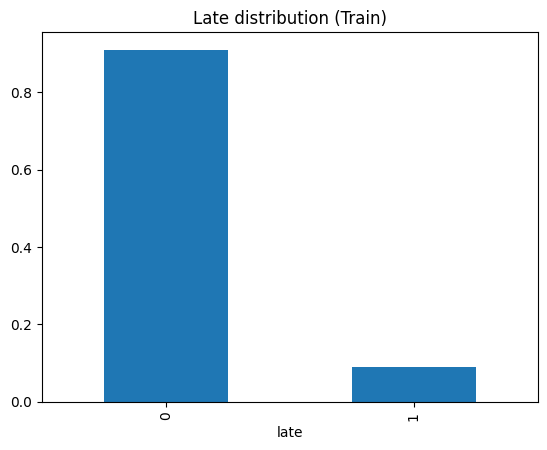

In [ ]:
plt.figure()
eda_df["late"].value_counts(normalize=True).plot(kind="bar")
plt.title("Late distribution (Train)")
plt.show()

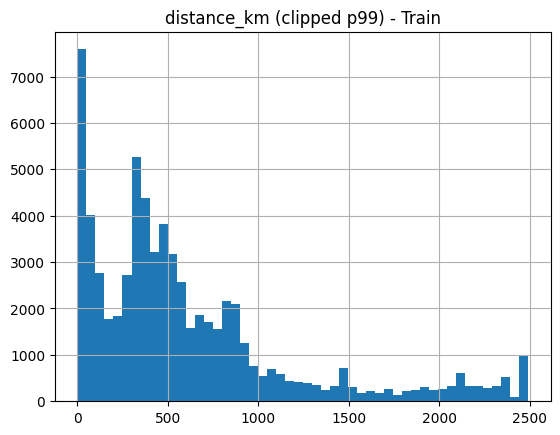

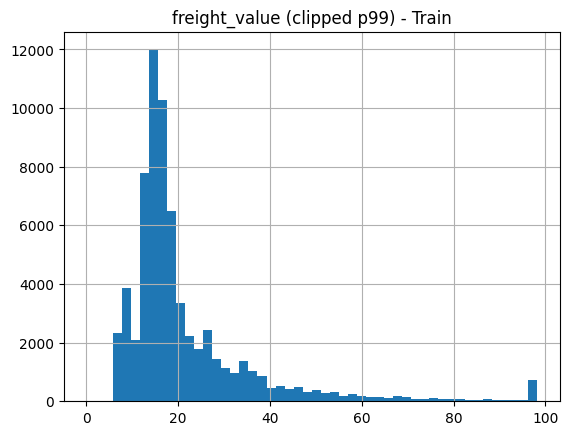

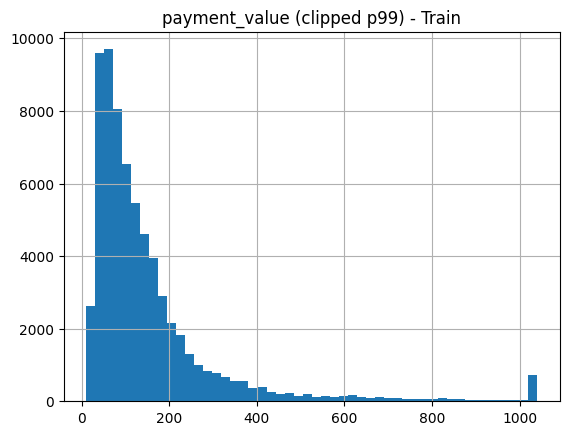

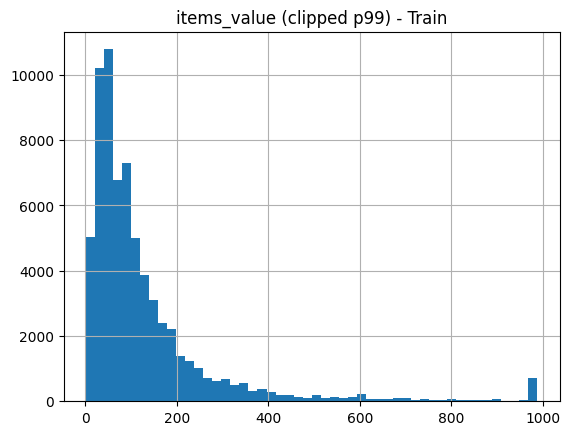

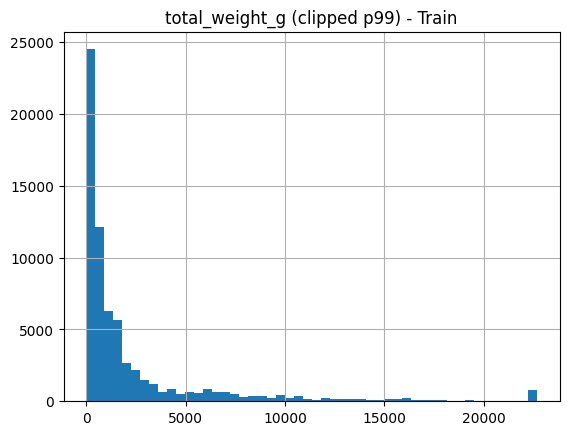

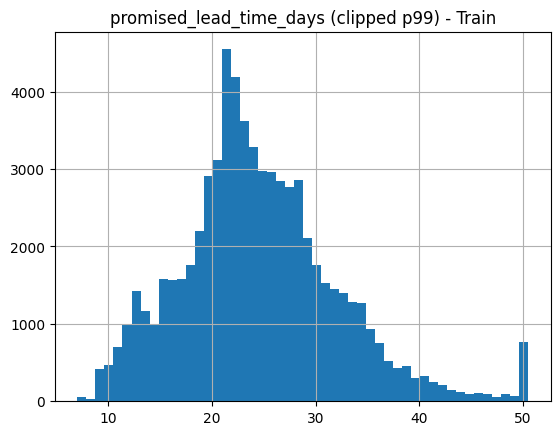

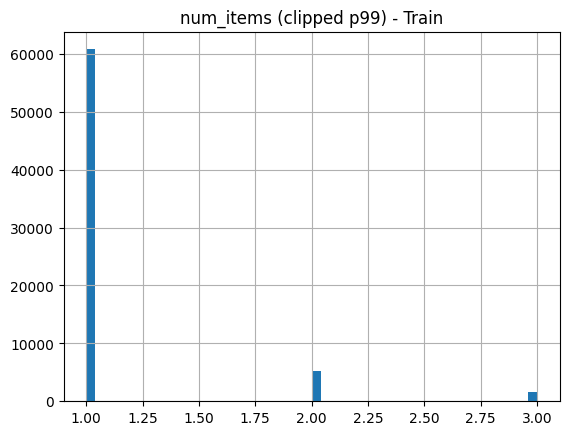

In [ ]:
for col in ["distance_km","freight_value","payment_value","items_value","total_weight_g","promised_lead_time_days","num_items"]:
    if col in eda_df.columns:
        plt.figure()
        eda_df[col].clip(upper=eda_df[col].quantile(0.99)).hist(bins=50)
        plt.title(f"{col} (clipped p99) - Train")
        plt.show()

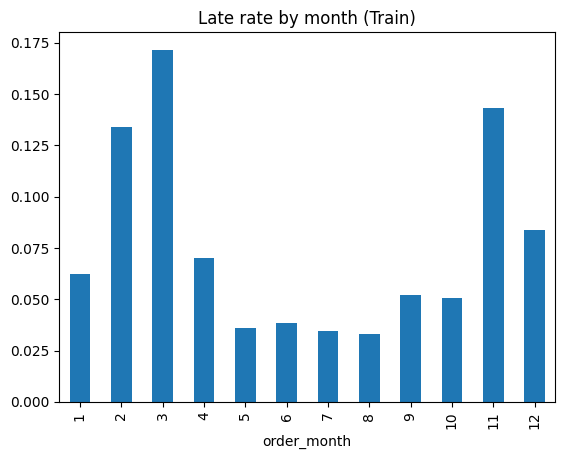

/tmp/ipython-input-2696854385.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(tmp.groupby("dist_bucket").agg(late_rate=("late","mean"), n=("late","size")))


,late_rate,n
dist_bucket,,
0-10,0.042225,1492
10-50,0.046962,6090
50-200,0.056879,8562
200-1000,0.093941,39993
1000+,0.132808,11031


In [ ]:
plt.figure()
eda_df.groupby("order_month")["late"].mean().plot(kind="bar")
plt.title("Late rate by month (Train)")
plt.show()

if "distance_km" in eda_df.columns:
    tmp = eda_df.copy()
    tmp["dist_bucket"] = pd.cut(tmp["distance_km"], bins=[0,10,50,200,1000,np.inf],
                                labels=["0-10","10-50","50-200","200-1000","1000+"])
    display(tmp.groupby("dist_bucket").agg(late_rate=("late","mean"), n=("late","size")))

## Insight & Kết luận nhanh từ EDA (Train/Val)

### 1) Nhãn bị mất cân bằng rõ rệt
- Biểu đồ phân bố `late` cho thấy lớp dương (`late=1` – giao trễ) chiếm tỷ lệ nhỏ (xấp xỉ **~8–10%** trên Train).
- **Hệ quả**:
  - `Accuracy` rất dễ “đẹp giả” (mô hình đoán tất cả *không trễ* vẫn có accuracy cao).
  - Ưu tiên metric **PR-AUC**, hoặc chọn threshold theo mục tiêu vận hành.
- **Quyết định**: dùng `PR-AUC` làm metric chính trong shortlist/tuning; dùng confusion matrix/F1 khi cần chốt ngưỡng.

---

### 2) Nhiều biến số có phân phối lệch phải (right-skewed) và đuôi dài (heavy tail)
- Histogram cho thấy các biến như:
  - `distance_km`, `freight_value`, `payment_value`, `items_value`, `total_weight_g`, `promised_lead_time_days`
  thường **tập trung ở vùng nhỏ** nhưng có một phần nhỏ **rất lớn** (long tail).
- **Hệ quả**:
  - Mean/std có thể bị kéo lệch; median/IQR đáng tin hơn.
  - Outlier không mặc định là lỗi: có thể là **case hiếm thật** (đơn cực xa, phí ship cao) – nhóm này đôi khi chính là nhóm rủi ro trễ.
- **Quyết định**:
  - Với pipeline tuyến tính: cân nhắc **log-transform**, **RobustScaler**
  - Với mô hình cây/boosting: không bắt buộc scaling, nhưng vẫn phải xử lý **giá trị lỗi** (âm/vô hạn) và kiểm tra các điểm cực đoan bất hợp lý.

---

### 3) Có dấu hiệu “cụm” trong phân phối khoảng cách (distance)
- Phân phối `distance_km` không đơn đỉnh hoàn toàn (có thể có cụm “gần” và “xa”), phản ánh các nhóm vận chuyển khác nhau.
- **Hệ quả**: các mối quan hệ có thể **phi tuyến** (đi xa hơn không làm rủi ro tăng đều theo tuyến tính).
- **Quyết định**:
  - Tạo `distance_bucket` (near/medium/far) để bắt phi tuyến dễ hơn.

---


## 6.6 Các thư viện hỗ trợ EDA nhanh và chuyên nghiệp

Khi làm EDA, mục tiêu là **nhìn nhanh – hiểu đúng – ra quyết định**, nên ta cần công cụ giúp:
- thống kê mô tả tự động,
- phát hiện giá trị thiếu / ngoại lệ,
- trực quan hoá nhanh,
- xem mối quan hệ giữa biến và nhãn.

Dưới đây là các thư viện rất hữu ích

### (1) `ydata-profiling` (trước đây là `pandas-profiling`)
- Tạo **báo cáo EDA tự động** (HTML) chỉ với vài dòng code.
- Hiển thị: missingness, phân phối, tương quan, cảnh báo dữ liệu bất thường…
- Phù hợp để *lấy overview* nhanh trước khi đi sâu.

**Khi nào nên dùng:**  
Khi bạn mới nhận dataset và muốn có “bức tranh tổng quan” trong 1 phút.

---

### (2) `sweetviz`
- Tạo report EDA nhanh, trực quan và dễ đọc.
- Có thể so sánh **train vs test** hoặc **2 tập dữ liệu** (hữu ích khi kiểm tra drift).

**Khi nào nên dùng:**  
Khi bạn muốn báo cáo EDA đẹp, trình bày cho người không chuyên.

---

### (3) `dtale`
- Mở giao diện giống spreadsheet để khám phá dữ liệu tương tác: filter, sort, plot…
- Rất tiện để debug dữ liệu tabular.

**Khi nào nên dùng:**  
Khi bạn muốn “lật dữ liệu” nhanh giống Excel nhưng vẫn giữ trong Python.

---

### (4) `missingno`
- Chuyên trực quan hoá dữ liệu bị thiếu: heatmap, matrix, bar…
- Giúp thấy pattern thiếu dữ liệu theo nhóm.

**Khi nào nên dùng:**  
Khi missingness là vấn đề lớn và bạn muốn nhìn pattern thiếu dữ liệu theo chiều thời gian/nhóm.

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(train_df, title="EDA Report - Train", explorative=True)
profile.to_file("eda_report_train.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 34/34 [00:12<00:00,  2.76it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5 3 6 ... 8 8 8]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 0 0 ... 9 9 9]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

---
# 7) Chọn tập đặc trưng và xây dựng quy trình tiền xử lý (theo từng nhóm mô hình)

Ở bước này, mục tiêu của chúng ta là:
1) xác định **những cột nào sẽ được dùng làm đầu vào** cho mô hình,
2) xây dựng **quy trình tiền xử lý tự động** để đảm bảo:
   - huấn luyện và dự đoán dùng **đúng cùng một cách xử lý**,
   - tránh sai khác giữa notebook và triển khai thực tế,
   - và có thể thay đổi mô hình mà không phải viết lại toàn bộ phần xử lý dữ liệu.

---

## 7.1 Vì sao phải tách quy trình tiền xử lý theo nhóm mô hình?
Không có một kiểu tiền xử lý nào “tối ưu cho mọi mô hình”.  
Đặc biệt với dữ liệu dạng bảng, hai nhóm mô hình hay dùng nhất là:

### Nhóm 1: Mô hình tuyến tính (ví dụ Logistic Regression)
Đặc điểm:
- mô hình học theo công thức tuyến tính,
- nhạy với thang đo của biến số (scale),
- không xử lý trực tiếp biến dạng chữ / dạng nhãn.

=> Cần:
- chuyển biến phân loại thành dạng số bằng **mã hoá 1-nhiều** (one-hot),
- chuẩn hoá các biến số (scaling) để mô hình học ổn định.

---

### Nhóm 2: Mô hình cây và tăng cường (ví dụ HistGradientBoosting)
Đặc điểm:
- mô hình dựa trên việc chia ngưỡng theo giá trị,
- ít nhạy với việc các biến số có thang đo khác nhau,
- có thể học quan hệ phi tuyến mạnh.

=> Thường:
- không cần chuẩn hoá (không bắt buộc scaling),
- có thể dùng **mã hoá thứ tự** (ordinal encoding) để giữ dữ liệu “dạng đặc” (dense), chạy nhanh và tiết kiệm bộ nhớ.

---

## 7.2 Quy trình tiền xử lý cho mô hình tuyến tính (One-hot + Chuẩn hoá)
Mục tiêu:
- biến số: điền khuyết bằng trung vị và chuẩn hoá
- biến phân loại: điền khuyết bằng giá trị phổ biến và mã hoá one-hot
- xử lý trường hợp “gặp nhãn mới” bằng cách bỏ qua (không gây lỗi)

Các bước điển hình:
- Biến số:
  - điền giá trị thiếu (trung vị)
  - thêm cột chỉ báo thiếu (tùy chọn)
  - chuẩn hoá
- Biến phân loại:
  - điền giá trị thiếu (phổ biến nhất)
  - mã hoá one-hot

---

## 7.3 Quy trình tiền xử lý cho mô hình cây/tăng cường (Ordinal encoding, không scaling)
Mục tiêu:
- biến số: điền khuyết (trung vị)
- biến phân loại: điền khuyết và mã hoá dạng số thứ tự
- nếu gặp nhãn mới: gán về một giá trị đặc biệt (ví dụ -1)

Các bước điển hình:
- Biến số:
  - điền giá trị thiếu (trung vị)
- Biến phân loại:
  - điền giá trị thiếu (phổ biến nhất)
  - mã hoá ordinal (nhãn mới → -1)

---

## 7.4 Lợi ích khi dùng “quy trình tiền xử lý” (pipeline)
Khi bạn đóng gói tiền xử lý + mô hình thành một pipeline:
- huấn luyện và dự đoán bằng **một câu lệnh thống nhất**,
- giảm nguy cơ sai khác giữa môi trường huấn luyện và triển khai,
- dễ thử nhiều mô hình khác nhau mà không đổi phần xử lý dữ liệu,
- dễ lưu mô hình để triển khai (vì pipeline đã chứa đầy đủ các bước).

---


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier

In [ ]:
TARGET = "late"

# Danh sách cột không được dùng làm feature (ID + forbidden + target)
DROP_AS_FEATURES = ["order_id", "customer_id", "seller_id"] + FORBIDDEN + [TARGET]

# Loại bỏ thêm các cột kiểu datetime khỏi feature_cols
datetime_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()

feature_cols = [
    c for c in df.columns
    if (c not in DROP_AS_FEATURES) and (c not in datetime_cols)
]

# tạo route_state(tuyến đường)
for _df in [df, train_df, val_df, test_df]:
    if "customer_state" in _df.columns and "seller_state" in _df.columns:
        _df["route_state"] = _df["customer_state"].astype(str) + "_" + _df["seller_state"].astype(str)

# thêm vào feature_cols
if "route_state" in df.columns and "route_state" not in feature_cols:
    feature_cols.append("route_state")

# 4) Tách cột phân loại và cột số
cat_cols = [c for c in ["customer_state", "seller_state", "payment_type_main", "route_state"] if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

# 5) X/y
X_train = train_df[feature_cols].copy(); y_train = train_df[TARGET].astype(int).copy()
X_val   = val_df[feature_cols].copy();   y_val   = val_df[TARGET].astype(int).copy()
X_test  = test_df[feature_cols].copy();  y_test  = test_df[TARGET].astype(int).copy()

print("num:", len(num_cols), "cat:", len(cat_cols), "features:", len(feature_cols))


num: 20 cat: 4 features: 24


In [ ]:
numeric_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
preprocess_linear = ColumnTransformer([
    ("num", numeric_linear, num_cols),
    ("cat", categorical_linear, cat_cols),
], remainder="drop")

numeric_tree = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
preprocess_tree = ColumnTransformer([
    ("num", numeric_tree, num_cols),
    ("cat", categorical_tree, cat_cols),
], remainder="drop")

# 8) Thiết lập mô hình cơ sở và chọn nhanh ứng viên (Baseline & Shortlisting)

Ở giai đoạn này, mục tiêu của chúng ta không phải “làm cho điểm số cao nhất”, mà là:
1) tạo **mốc so sánh tối thiểu** để biết mô hình máy học có thực sự mang lại giá trị hay không,
2) thử nhanh một vài mô hình phù hợp để **khoanh vùng ứng viên tiềm năng** trước khi tinh chỉnh sâu.

---

## 8.1 Vì sao phải có mô hình cơ sở (baseline)?
Nếu không có baseline, bạn sẽ không biết:
- mô hình hiện tại tốt hơn “đoán mò” bao nhiêu,
- cải thiện là thật hay do ngẫu nhiên,
- dữ liệu có đủ tín hiệu để học hay không.

**Baseline giống như “mốc chuẩn tối thiểu”**:
- Nếu mô hình phức tạp không vượt baseline → khả năng cao là vấn đề nằm ở dữ liệu, nhãn, hoặc rò rỉ/thiếu đặc trưng.

---

## 8.2 Baseline nên có những loại nào?
Trong dự án thực tế, baseline thường có 2 tầng:

### (1) Baseline tối thiểu: mô hình “ngây thơ”
Ví dụ:
- luôn dự đoán theo lớp phổ biến nhất,
- hoặc dự đoán ngẫu nhiên theo tỷ lệ lớp.

Mục tiêu:
- tạo mốc “thấp nhất”, đảm bảo mô hình học máy **ít nhất phải tốt hơn mức này**.

---

### (2) Baseline có giá trị: mô hình đơn giản nhưng nghiêm túc
Một lựa chọn rất phổ biến:
- mô hình tuyến tính (ví dụ Logistic Regression)

Ưu điểm:
- huấn luyện nhanh, ổn định,
- dễ diễn giải,
- thường đủ mạnh để làm mốc so sánh “đáng tin”.

---

## 8.3 Chọn nhanh ứng viên (shortlisting):
Sau baseline, ta cần thử nhanh một số mô hình thuộc các “họ” khác nhau để xem:
- mô hình nào phù hợp nhất với dữ liệu,
- mô hình nào đáng để đầu tư tinh chỉnh ở bước tiếp theo.

Với dữ liệu dạng bảng như bài toán giao hàng, các nhóm mô hình hay dùng:
- **mô hình tuyến tính**: ổn định, dễ triển khai, dễ giải thích
- **mô hình cây/tăng cường**: mạnh cho bảng, bắt quan hệ phi tuyến và tương tác đặc trưng tốt

---

## 8.4 Đánh giá nhanh cần chú ý điều gì?
Để so sánh công bằng, ta phải giữ cố định:
- cách chia train/validation (theo thời gian),
- quy trình tiền xử lý,
- thước đo đánh giá.

Vì bài toán có thể mất cân bằng lớp, ta ưu tiên các thước đo như:
- **PR-AUC** (phù hợp khi lớp “giao trễ” là lớp hiếm)
- F1 và ma trận nhầm lẫn (để hiểu lỗi theo hướng vận hành)

---

## 8.5 Kết quả cần đạt sau bước này
Sau Baseline & Shortlisting, ta phải chốt được:
- mô hình nào vượt baseline rõ ràng,
- mô hình nào là **ứng viên chính** để đem đi tinh chỉnh tham số ở bước tiếp theo (tuning),
- và có hiểu biết sơ bộ: mô hình đang sai theo kiểu gì (để chuẩn bị phân tích lỗi ở phần sau).

---

In [ ]:
def eval_proba(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred),
        "cm": confusion_matrix(y_true, pred),
    }

def print_eval(name, res):
    print(f"\n== {name} ==")
    print("PR-AUC:", res["pr_auc"])
    print("F1:", res["f1"])
    print("Confusion matrix:\n", res["cm"])

In [ ]:
dummy = Pipeline([
    ("prep", preprocess_linear),
    ("model", DummyClassifier(strategy="most_frequent"))
])
dummy.fit(X_train, y_train)
proba_d = dummy.predict_proba(X_val)[:, 1]
print_eval("Dummy", eval_proba(y_val, proba_d))


== Dummy ==
PR-AUC: 0.053420870767104355
F1: 0.0
Confusion matrix:
 [[13697     0]
 [  773     0]]


In [ ]:
logreg = Pipeline([
    ("prep", preprocess_linear),
    ("model", LogisticRegression(max_iter=400, class_weight="balanced", random_state=RANDOM_STATE))
])
logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_val)[:, 1]
print_eval("LogReg", eval_proba(y_val, proba_lr))


== LogReg ==
PR-AUC: 0.1672083634321788
F1: 0.20091827364554637
Confusion matrix:
 [[9572 4125]
 [ 226  547]]


In [ ]:
hgb = Pipeline([
    ("prep", preprocess_tree),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])
hgb.fit(X_train, y_train)
proba_hgb = hgb.predict_proba(X_val)[:, 1]
print_eval("HGB", eval_proba(y_val, proba_hgb))


== HGB ==
PR-AUC: 0.1395408191989244
F1: 0.007692307692307693
Confusion matrix:
 [[13693     4]
 [  770     3]]


---
# 9) Tinh chỉnh tham số mô hình (RandomizedSearch → có thể tinh chỉnh tiếp bằng GridSearch) với chia chéo theo thời gian

Sau khi đã có **mô hình ứng viên** (ví dụ mô hình LogisticRegresion) và quy trình tiền xử lý ổn định, bước tiếp theo là **tinh chỉnh tham số** để mô hình đạt hiệu năng tốt hơn.

Mục tiêu của phần này:
1) tìm ra cấu hình tham số tốt trong phạm vi “ngân sách thử nghiệm” cho phép,
2) đảm bảo việc đánh giá trong quá trình tinh chỉnh **mô phỏng đúng production** bằng cách chia theo thời gian,
3) tránh chọn mô hình do “ăn may” trên một lần chia dữ liệu.

---

## 9.1 Vì sao cần chia chéo theo thời gian khi tinh chỉnh?
Trong dữ liệu vận hành, phân phối dữ liệu có thể thay đổi theo thời gian (mùa vụ, thay đổi quy trình…).  
Nếu dùng chia chéo ngẫu nhiên, mô hình sẽ được đánh giá trên dữ liệu “trộn thời gian”, dễ lạc quan hơn thực tế.

Vì vậy, ở đây ta dùng **chia chéo theo thời gian**:
- tập huấn luyện ở “quá khứ”
- tập kiểm định ở “tương lai gần”
và lặp lại theo nhiều cửa sổ thời gian để tăng độ tin cậy.

Nói đơn giản: ta huấn luyện nhiều lần theo kiểu  
**học từ đoạn thời gian trước → kiểm tra trên đoạn thời gian sau**.

---

## 9.2 Hai chiến lược tinh chỉnh tham số: tìm nhanh rồi chốt
### (1) Tìm nhanh bằng tìm kiếm ngẫu nhiên (RandomizedSearch)
- Ta định nghĩa một “không gian tham số” (ví dụ: độ sâu cây, tốc độ học, số lá…).
- Sau đó cho thuật toán thử **một số lượng cấu hình hữu hạn** (ví dụ 20 cấu hình).
- Ưu điểm: nhanh và hiệu quả khi không gian tham số lớn.
- Nhược điểm: không đảm bảo thử hết mọi tổ hợp.

### (2) (Tuỳ chọn) Chốt lại bằng tìm kiếm theo lưới (GridSearch)
Sau khi đã tìm được một vùng tham số tốt bằng tìm kiếm ngẫu nhiên, ta có thể:
- thu hẹp phạm vi quanh giá trị tốt nhất,
- rồi dùng GridSearch để “tinh chỉnh mịn” (fine-grained) trong vùng đó.

Ưu điểm: giúp tối ưu cẩn thận hơn quanh vùng tốt.  
Nhược điểm: tốn thời gian nếu phạm vi còn lớn.

> Thực tế triển khai thường dùng chiến lược:  
> **tìm kiếm ngẫu nhiên trước để do thám → nếu cần mới dùng lưới để chốt.**

---

## 9.3 Chọn thước đo đánh giá khi tinh chỉnh
Vì bài toán có thể mất cân bằng lớp (giao trễ thường ít hơn không trễ), nên:
- ta ưu tiên **PR-AUC** để đo khả năng xếp hạng đúng các đơn rủi ro,
- sau đó mới chọn ngưỡng quyết định (top-k hoặc tối ưu F1) ở bước kế tiếp.

---

## 9.4 Kết quả cần đạt sau bước này
Sau phần tinh chỉnh, ta phải có:
- mô hình tốt nhất theo tiêu chí PR-AUC (dựa trên chia chéo theo thời gian),
- bộ tham số tương ứng,
- sẵn sàng chuyển sang bước chọn ngưỡng quyết định (chính sách vận hành) và đánh giá cuối.

---


In [ ]:
tscv = TimeSeriesSplit(n_splits=3)

logreg = Pipeline([
    ("prep", preprocess_linear),
    ("model", LogisticRegression(
        max_iter=400,
        random_state=RANDOM_STATE
    ))
])

param_dist = {
    "model__C": np.logspace(-3, 2, 25),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"],
    "model__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 8}
    ],
}

rand_search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rand_search.fit(X_train, y_train)
print("Best PR-AUC (CV):", rand_search.best_score_)
print("Best params:", rand_search.best_params_)

best_logreg = rand_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best PR-AUC (CV): 0.20008470336225445
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__class_weight': {0: 1, 1: 5}, 'model__C': np.float64(0.07498942093324558)}


In [ ]:
best_C = rand_search.best_params_["model__C"]
best_penalty = rand_search.best_params_["model__penalty"]
best_solver = rand_search.best_params_["model__solver"]
best_cw = rand_search.best_params_["model__class_weight"]

grid = {
    "model__C": [best_C/3, best_C, best_C*3],
    "model__penalty": [best_penalty],
    "model__solver": [best_solver],
    "model__class_weight": [best_cw],
}

grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=grid,
    scoring="average_precision",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Grid best PR-AUC:", grid_search.best_score_)
print("Grid best params:", grid_search.best_params_)

best_logreg = grid_search.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Grid best PR-AUC: 0.20082149448138617
Grid best params: {'model__C': np.float64(0.024996473644415193), 'model__class_weight': {0: 1, 1: 5}, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


---
# 10) Xác định ngưỡng ra quyết định (chính sách cảnh báo top-k) và (tuỳ chọn) ngưỡng tối ưu F1

Sau khi đã có mô hình tốt nhất (từ bước tinh chỉnh tham số), mô hình thường trả ra:
- **xác suất giao trễ** cho mỗi đơn hàng.

Tuy nhiên, trong triển khai thực tế, chúng ta cần chuyển xác suất đó thành **quyết định hành động**:
- đơn nào cần cảnh báo / ưu tiên can thiệp,
- đơn nào không cần.

Vì vậy, bước này không còn là “tối ưu mô hình”, mà là **xây dựng chính sách ra quyết định** phù hợp với vận hành.

---

## 10.1 Vì sao không dùng ngưỡng mặc định 0.5?
Nhiều người mới học hay dùng ngưỡng 0.5 (lớn hơn 0.5 thì dự đoán trễ).  
Nhưng ngưỡng này **không có ý nghĩa đặc biệt** trong phần lớn bài toán thực tế, vì:
- dữ liệu mất cân bằng: lớp “trễ” có thể rất ít,
- chi phí sai khác nhau:
  - bỏ sót một đơn trễ (không cảnh báo) có thể gây hậu quả lớn,
  - trong khi cảnh báo nhầm một số đơn không trễ có thể chỉ tốn công kiểm tra.

Do đó, ngưỡng phải được chọn theo mục tiêu cụ thể, không chọn theo thói quen.

---

## 10.2 Chính sách phổ biến nhất trong vận hành: cảnh báo theo top-k
Trong nhiều hệ thống, đội vận hành có giới hạn năng lực xử lý, ví dụ:
- chỉ có thể kiểm tra và can thiệp tối đa 5% số đơn mỗi ngày.

Khi đó, chính sách tự nhiên là:
- xếp hạng đơn hàng theo xác suất trễ từ cao xuống thấp,
- **chọn top-k%** đơn có rủi ro cao nhất để cảnh báo.

Ưu điểm của top-k:
- bám sát năng lực vận hành (không tạo ra số cảnh báo vượt khả năng xử lý),
- ổn định hơn trong thực tế so với một ngưỡng cố định,
- dễ giải thích với phía nghiệp vụ: “mỗi ngày ta chỉ xử lý nhóm rủi ro cao nhất”.

Chỉ số nên báo cáo kèm theo:
- **precision@top-k**: trong nhóm được cảnh báo, bao nhiêu phần trăm thật sự trễ?
- **recall@top-k**: trong tất cả các đơn trễ, ta bắt được bao nhiêu phần trăm?

---

## 10.3 (Tuỳ chọn) Chọn ngưỡng tối ưu theo F1
Trong các bài toán học thuật hoặc khi muốn cân bằng giữa:
- bắt được nhiều đơn trễ (recall),
- và giảm cảnh báo nhầm (precision),

ta có thể chọn ngưỡng sao cho **F1 lớn nhất** trên tập kiểm định (validation).

Lưu ý:
- F1 chỉ là một cách chọn ngưỡng theo tiêu chí kỹ thuật,
- không đảm bảo phù hợp với vận hành nếu đội xử lý chỉ giới hạn số lượng cảnh báo.

Vì vậy, trong dự án end-to-end, tốt nhất là:
- dùng **top-k** như chính sách chính,
- và dùng “tối ưu F1” như một phương án so sánh hoặc minh hoạ.

---

## 10.4 Nguyên tắc quan trọng khi chọn ngưỡng
- Ngưỡng/chính sách phải được chọn **trên tập kiểm định (validation)**.
- Sau khi đã chốt chính sách, ta mới được đánh giá một lần trên **tập kiểm tra cuối (test)**.

> Đây là điểm rất quan trọng để tránh “tinh chỉnh ngưỡng theo test”, dẫn đến đánh giá sai và mô hình không đáng tin.

---


In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import numpy as np

prec, rec, thr = precision_recall_curve(y_val, proba_val)

f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s))

thr_idx = min(best_idx, len(thr)-1)
thr_f1 = float(thr[thr_idx])
print("Best-F1 threshold:", thr_f1, "F1:", float(f1s[best_idx]))

thr_topk = float(np.quantile(proba_val, 1 - TOP_K))
print(f"Top-k threshold (k={TOP_K:.0%}):", thr_topk)


Best-F1 threshold: 0.5229808405331218 F1: 0.25312800769924404
Top-k threshold (k=5%): 0.5933163866682081


In [ ]:
def precision_recall_at_k(y_true, proba, k=0.05):
    thr = float(np.quantile(proba, 1 - k))
    pred = (proba >= thr).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return thr, precision, recall, pred.mean()

thr_k, p_k, r_k, alert_rate = precision_recall_at_k(
    y_val.values if hasattr(y_val, "values") else y_val,
    proba_val,
    k=TOP_K
)

print(f"VAL top-k={TOP_K:.0%}: thr={thr_k:.4f}, precision={p_k:.3f}, recall={r_k:.3f}, alert_rate={alert_rate:.3f}")

VAL top-k=5%: thr=0.5933, precision=0.244, recall=0.229, alert_rate=0.050


---
# 11) Kết hợp mô hình (Ensemble) bằng bỏ phiếu mềm — Logistic Regression + mô hình tăng cường đã tinh chỉnh

Sau khi đã có một mô hình tốt (ví dụ mô hình Logreg đã được tinh chỉnh tham số), ta có thể cân nhắc một kỹ thuật nâng cao: **kết hợp nhiều mô hình** để tăng độ ổn định và (đôi khi) tăng hiệu năng.

Trong notebook này, ta minh hoạ cách kết hợp:
- một mô hình tuyến tính (Logistic Regression),
- và một mô hình phi tuyến mạnh cho dữ liệu dạng bảng (mô hình tăng cường).

---

## 11.1 Vì sao kết hợp mô hình có thể giúp tốt hơn?
Mỗi mô hình có “điểm mạnh” khác nhau:
- Logistic Regression thường:
  - ổn định,
  - tổng quát tốt,
  - không dễ bị quá khớp khi dữ liệu có nhiễu,
  - dễ triển khai và giải thích.
- Mô hình tăng cường thường:
  - bắt được quan hệ phi tuyến,
  - học tốt tương tác giữa các đặc trưng,
  - thường mạnh hơn với dữ liệu dạng bảng.

Khi kết hợp, ta kỳ vọng:
- giảm rủi ro mô hình bị lệch theo một kiểu sai cụ thể,
- tăng độ ổn định khi dữ liệu thay đổi nhẹ.

---

## 11.2 “Bỏ phiếu mềm” là gì?
“Bỏ phiếu mềm” nghĩa là:
- mỗi mô hình trả ra **xác suất giao trễ** cho từng đơn,
- ta lấy **trung bình (hoặc trung bình có trọng số)** các xác suất này,
- sau đó mới áp dụng chính sách ngưỡng (top-k hoặc ngưỡng tối ưu F1).

Điểm quan trọng:
- bỏ phiếu mềm **khai thác thông tin xác suất**, thường hiệu quả hơn bỏ phiếu cứng (chỉ dự đoán 0/1).

---

## 11.3 Khi nào nên dùng ensemble trong dự án thực tế?
Ensemble không phải lúc nào cũng đáng. Ta chỉ nên dùng khi:
- hiệu năng tăng đủ rõ rệt (ví dụ tăng PR-AUC đáng kể hoặc cải thiện recall@top-k),
- chi phí triển khai chấp nhận được.

Vì ensemble có “giá phải trả”:
- dự đoán chậm hơn (phải chạy nhiều mô hình),
- hệ thống phức tạp hơn,
- khó theo dõi và debug hơn,
- khó giải thích hơn so với mô hình đơn.

---

## 11.4 Cách ra quyết định cuối cùng
Trong notebook, sau khi xây ensemble, ta sẽ:
- so sánh hiệu năng trên tập kiểm định (validation),
- kiểm tra theo đúng chính sách top-k (precision@top-k, recall@top-k),
- nếu ensemble không cải thiện đáng kể → ưu tiên mô hình đơn giản để dễ triển khai.

> Đây là tư duy end-to-end quan trọng: **không phải cái gì điểm cao hơn một chút cũng đáng triển khai**.

---


In [ ]:
ens = VotingClassifier(
    estimators=[("lr", best_logreg), ("hgb", hgb)],
    voting="soft",
    weights=[2, 1]
)

ens.fit(X_train, y_train)
proba_val_ens = ens.predict_proba(X_val)[:, 1]

print("VAL PR-AUC(Ensemble lr+hgb):", average_precision_score(y_val, proba_val_ens))

thr_k_ens, p_k_ens, r_k_ens, alert_rate_ens = precision_recall_at_k(
    y_val.values if hasattr(y_val, "values") else y_val,
    proba_val_ens,
    k=TOP_K
)
print(f"VAL ensemble top-k={TOP_K:.0%}: thr={thr_k_ens:.4f}, precision={p_k_ens:.3f}, recall={r_k_ens:.3f}, alert_rate={alert_rate_ens:.3f}")

VAL PR-AUC(Ensemble lr+hgb): 0.17651818458467244
VAL ensemble top-k=5%: thr=0.4347, precision=0.257, recall=0.241, alert_rate=0.050


---
# 12) Đánh giá cuối cùng trên tập kiểm tra

Mục tiêu của bước này là **đánh giá khách quan** năng lực tổng quát của mô hình trên dữ liệu “mới nhất”, mô phỏng tình huống triển khai thực tế.

Điểm quan trọng nhất:
> **Tập kiểm tra (test) chỉ được dùng đúng một lần**, sau khi mọi quyết định đã chốt.

---

## 12.1 Vì sao “test chỉ dùng một lần”?
Trong quy trình end-to-end, tập kiểm tra đóng vai trò như:
- dữ liệu tương lai,
- dữ liệu mà nhóm phát triển không được phép “nhìn trước” khi ra quyết định.

Nếu ta dùng test để:
- chọn mô hình,
- chọn tham số,
- chọn ngưỡng cảnh báo,
- hoặc chọn cách kết hợp mô hình,

thì ta đã vô tình “học theo đề thi”, dẫn đến kết quả đánh giá bị ảo và không còn đáng tin.

---

## 12.2 Chốt mô hình cuối (final model)
Tại thời điểm này, ta đã có ít nhất một mô hình ứng viên tốt:
- **mô hình tăng cường đã tinh chỉnh** (ví dụ `best_logres`)
- và có thể có thêm **mô hình kết hợp** (ensemble) nếu nó cải thiện rõ rệt.

Ta chỉ chọn ensemble nếu nó:
- cải thiện đáng kể các chỉ số quan trọng (PR-AUC, recall@top-k, precision@top-k),
- và chi phí triển khai vẫn hợp lý.

Nếu không, ta ưu tiên mô hình đơn vì:
- dễ triển khai,
- dễ giám sát,
- dễ giải thích.

---

## 12.3 Đánh giá trên tập kiểm tra cần báo cáo gì?
Ở bước cuối, ta thường báo cáo 2 nhóm chỉ số:

### (1) Chỉ số đánh giá chất lượng xếp hạng
- **PR-AUC**: đo khả năng mô hình xếp đúng các đơn hàng rủi ro cao lên trên.

### (2) Chỉ số gắn với quyết định vận hành (policy)
Vì mô hình sẽ được dùng theo chính sách cảnh báo top-k, cần báo cáo:
- **precision@top-k**: trong nhóm được cảnh báo, bao nhiêu % thật sự trễ?
- **recall@top-k**: trong tất cả các đơn trễ, ta bắt được bao nhiêu %?


In [ ]:
FINAL_MODEL = best_logreg
FINAL_NAME  = "best_logreg"

proba_val_lr = best_logreg.predict_proba(X_val)[:, 1]
thr_k_lr, p_k_lr, r_k_lr, alert_rate_lr = precision_recall_at_k(
    y_val.values if hasattr(y_val, "values") else y_val,
    proba_val_lr,
    k=TOP_K
)

thr_final = thr_k_lr
print("Final:", FINAL_NAME, "| threshold(top-k on VAL):", thr_final)
print(f"VAL best_logreg top-k={TOP_K:.0%}: thr={thr_k_lr:.4f}, precision={p_k_lr:.3f}, recall={r_k_lr:.3f}, alert_rate={alert_rate_lr:.3f}")

Final: best_logreg | threshold(top-k on VAL): 0.5933163866682081
VAL best_logreg top-k=5%: thr=0.5933, precision=0.244, recall=0.229, alert_rate=0.050


In [ ]:
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix

proba_test = FINAL_MODEL.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= thr_final).astype(int)

print("TEST PR-AUC:", average_precision_score(y_test, proba_test))
print("TEST F1:", f1_score(y_test, pred_test))
print("TEST CM:\n", confusion_matrix(y_test, pred_test))

thr_tmp, p_tmp, r_tmp, alert_rate_tmp = precision_recall_at_k(
    y_test.values if hasattr(y_test, "values") else y_test,
    proba_test,
    k=TOP_K
)
print(f"TEST top-k={TOP_K:.0%}: thr={thr_tmp:.4f}, precision={p_tmp:.3f}, recall={r_tmp:.3f}, alert_rate={alert_rate_tmp:.3f}")


TEST PR-AUC: 0.11248001404996866
TEST F1: 0.12859424920127796
TEST CM:
 [[12128  1386]
 [  796   161]]
TEST top-k=5%: thr=0.6711, precision=0.145, recall=0.110, alert_rate=0.050


---
# 13) Lưu mô hình và thông tin kèm theo để triển khai
Sau khi đã đánh giá xong và chọn được mô hình cuối, bước tiếp theo là **đóng gói kết quả** để:
- có thể triển khai sang môi trường khác (máy chủ, dịch vụ, batch job),
- có thể tái sử dụng mà không cần chạy lại toàn bộ notebook,
- và có thể kiểm soát phiên bản, truy vết (audit) khi có vấn đề phát sinh.

Nói đơn giản: đây là bước biến “kết quả notebook” thành **một sản phẩm có thể chạy được**.

---

## 13.1 Ta cần lưu những gì?
Một dự án end-to-end tối thiểu nên lưu 2 nhóm:

### (1) Mô hình có thể dự đoán trực tiếp
Ta lưu **toàn bộ quy trình** (không chỉ lưu riêng mô hình), bao gồm:
- tiền xử lý dữ liệu (điền khuyết, mã hoá, chuẩn hoá…),
- mô hình học máy,
- và bất kỳ bước biến đổi nào đã dùng trong huấn luyện.

Lý do:
- khi triển khai, ta cần đảm bảo dữ liệu đầu vào được xử lý **giống hệt lúc huấn luyện**,
- tránh lỗi “lúc train xử lý một kiểu, lúc deploy xử lý kiểu khác”.

---

### (2) Thông tin kèm theo (metadata)
Metadata là “hồ sơ” của mô hình, giúp triển khai và giám sát dễ dàng hơn.  
Ví dụ metadata nên có:
- phiên bản mô hình,
- thời điểm tạo mô hình,
- danh sách cột đầu vào mà mô hình yêu cầu (schema),
- chính sách ra quyết định (ví dụ top-k hoặc ngưỡng cảnh báo),
- khoảng thời gian dữ liệu dùng để huấn luyện và kiểm tra,
- danh sách cột bị cấm (để nhắc lại quy tắc chống rò rỉ dữ liệu).

---

## 13.2 Vì sao metadata quan trọng?
Trong thực tế, khi mô hình có vấn đề, người ta sẽ hỏi:
- mô hình này được huấn luyện khi nào?
- dùng những cột nào?
- đang dùng chính sách ngưỡng gì?
- dữ liệu huấn luyện thuộc giai đoạn nào?

Nếu không có metadata:
- rất khó debug,
- khó so sánh giữa các phiên bản,
- khó rollback nếu mô hình mới tệ hơn.

Nói cách khác: metadata giúp mô hình **có thể quản trị được**, không chỉ “chạy được”.


In [ ]:
from pathlib import Path
from datetime import datetime
import joblib, json

ART_DIR = Path("models")
ART_DIR.mkdir(exist_ok=True)

model_path = ART_DIR / f"late_delivery_{FINAL_NAME}.joblib"
meta_path  = ART_DIR / f"late_delivery_{FINAL_NAME}_metadata.json"

joblib.dump(FINAL_MODEL, model_path)

metadata = {
    "model_version": "v1",
    "created_at_utc": datetime.utcnow().isoformat(),
    "final_model": FINAL_NAME,
    "note": "Đã thử ensemble (lr+hgb) nhưng hiệu năng giảm, chọn logreg làm final",
    "policy": {"type":"topk", "k": float(TOP_K), "threshold_on_val": float(thr_final)},
    "features_expected": feature_cols,
    "forbidden_columns": FORBIDDEN,
    "train_time_range": [str(train_df["order_purchase_timestamp"].min()), str(train_df["order_purchase_timestamp"].max())],
    "test_time_range":  [str(test_df["order_purchase_timestamp"].min()), str(test_df["order_purchase_timestamp"].max())],
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved model:", model_path)
print("Saved metadata:", meta_path)

Saved model: models/late_delivery_best_logreg.joblib
Saved metadata: models/late_delivery_best_logreg_metadata.json


/tmp/ipython-input-4045043604.py:15: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": datetime.utcnow().isoformat(),
